# 04 - Metric Space Analysis

Computes four distributional distance metrics between the unpruned model
(level=0) and each pruned model (level=20/40/60/80) using the top-5
teacher-forced logprob data collected in `02_eval_all.ipynb`.

**Metrics**
| Metric | Description | Alignment |
|--------|-------------|----------|
| KLD | Sum of KL(P_base ‖ P_pruned) per token position | position-aligned |
| JSD | Sum of √JSD(P_base, P_pruned) per token position | position-aligned |
| EMD | Wasserstein-1 on logprob values per position | position-aligned |
| Chamfer | Nearest-neighbour distance in R^\|vocab\| over all positions | set-based |

For KLD/JSD/EMD each token position in the answer contributes one scalar;
those are summed over the sequence.  For Chamfer, each position contributes
one sparse point in vocabulary space ({token_id: probability}); the Chamfer
distance is computed between the two *sets* of N such points, with
nearest-neighbour matching across positions.

**Goal**: Assess whether these distributional metrics predict cross-task
"brittleness" (drop in pass@1 under pruning) better than perplexity alone,
and measure R² for each metric vs. performance drop.

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "pyproject.toml").is_file():
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / ".env", override=False)
except ImportError:
    pass

print("REPO_ROOT =", REPO_ROOT)

REPO_ROOT = /var/home/three-kingdoms/work/pruning-metrics


## Configuration

In [2]:
import json
import boto3

AWS_PROFILE    = os.environ.get("AWS_PROFILE", "rengz")
RESULTS_BUCKET = os.environ.get("RESULTS_BUCKET", "pruning-metrics-results-414266451290")

# Notebooks are run from their own directory; cwd() is reliable in Jupyter.
NOTEBOOK_DIR = Path.cwd()
RESULTS_DIR  = NOTEBOOK_DIR / "results"

experiment_config_path = NOTEBOOK_DIR / "experiment_config.json"
_cfg = json.loads(experiment_config_path.read_text(encoding="utf-8"))

TF_URIS       = _cfg["teacher_forced_uris"]   # {"gsm8k_humaneval": "s3://...", ...}
FREEFORM_URIS = _cfg["freeform_eval_uris"]    # {"gsm8k_humaneval": "s3://...", ...}

PRUNING_LEVELS = [0, 20, 40, 60, 80]
DATASETS = ["arc_challenge", "gsm8k", "humaneval"]
BENCHMARK_LABELS = {
    "gsm8k":         "GSM8K",
    "humaneval":     "HumanEval+",
    "arc_challenge": "ARC-Challenge",
}

# Local cache for downloaded per_token.json files (~470 MB total, downloaded once).
TF_CACHE_DIR = RESULTS_DIR / "tf_cache"
TF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

session = boto3.session.Session(profile_name=AWS_PROFILE)
s3      = session.client("s3")


def _parse_combo(combo_key: str) -> tuple[str, str]:
    """Split 'cal_eval' correctly — dataset names like 'arc_challenge' contain underscores."""
    for cal in DATASETS:
        if combo_key.startswith(cal + "_"):
            return cal, combo_key[len(cal) + 1:]
    raise ValueError(f"Cannot parse combo_key: {combo_key!r}")


print(f"TF runs:      {len(TF_URIS)}")
print(f"Freeform runs: {len(FREEFORM_URIS)}")
for k in sorted(TF_URIS):
    print(f"  {k}: {TF_URIS[k]}")

TF runs:      9
Freeform runs: 9
  arc_challenge_arc_challenge: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T235425Z-9620ae/
  arc_challenge_gsm8k: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T224910Z-055d0e/
  arc_challenge_humaneval: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T224947Z-329c51/
  gsm8k_arc_challenge: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T235318Z-049f50/
  gsm8k_gsm8k: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T224607Z-3dee0b/
  gsm8k_humaneval: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T224640Z-95ff5b/
  humaneval_arc_challenge: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T235351Z-036a42/
  humaneval_gsm8k: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T224730Z-7b5dc5/
  humaneval_humaneval: s3://pruning-metrics-results-414266451290/teacher_forced/20260506T224803Z-d3beaa/


## Install scipy if needed

In [3]:
try:
    import scipy  # noqa: F401
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "scipy"], check=True)
    import scipy  # noqa: F401

## Import metric functions

In [4]:
from pruning_metrics.metrics import compute_kld, compute_jsd, compute_emd, compute_chamfer

print("Metrics loaded:", [f.__name__ for f in (compute_kld, compute_jsd, compute_emd, compute_chamfer)])

Metrics loaded: ['compute_kld', 'compute_jsd', 'compute_emd', 'compute_chamfer']


## Load freeform brittleness data

Downloads `summary.json` for each of the 9 freeform eval runs and computes
`pass_at_1_drop = pass_at_1(level=0) − pass_at_1(level=k)` per (cal, eval, level).
Runs whose `ended_at_utc` is null are still in progress — completed levels are
included, so preliminary results are available even before a run finishes.

In [5]:
import pandas as pd

def _get_freeform_summary(uri: str) -> dict | None:
    bucket = uri[5:].split("/", 1)[0]
    prefix = uri[5:].split("/", 1)[1].rstrip("/")
    try:
        body = s3.get_object(Bucket=bucket, Key=prefix + "/summary.json")["Body"].read()
        return json.loads(body)
    except Exception as exc:
        print(f"  SKIP {uri}: {exc}")
        return None

freeform_rows = []
for combo_key, uri in FREEFORM_URIS.items():
    cal, eval_ = _parse_combo(combo_key)
    summary = _get_freeform_summary(uri)
    if summary is None:
        continue
    if summary.get("ended_at_utc") is None:
        n_levels = len(summary.get("levels", []))
        print(f"  NOTE {combo_key}: still running — using {n_levels} completed level(s)")
    levels_data = {
        entry["pruning_level"]: entry.get("pass_at_1")
        for entry in summary.get("levels", [])
    }
    base_acc = levels_data.get(0.0)
    if base_acc is None:
        print(f"  SKIP {combo_key}: no level=0 entry")
        continue
    for level, acc in levels_data.items():
        if acc is not None:
            freeform_rows.append({
                "cal":           cal,
                "eval":          eval_,
                "pruning_level": level,
                "pass_at_1":     acc,
                "pass_at_1_drop": base_acc - acc,
            })

freeform_df = (
    pd.DataFrame(freeform_rows)
    .sort_values(["cal", "eval", "pruning_level"])
    .reset_index(drop=True)
)
print(f"Freeform rows loaded: {len(freeform_df)}")
freeform_df.head(26)

  NOTE gsm8k_arc_challenge: still running — using 4 completed level(s)
  NOTE humaneval_arc_challenge: still running — using 4 completed level(s)
Freeform rows loaded: 43


,cal,eval,pruning_level,pass_at_1,pass_at_1_drop
0,arc_challenge,arc_challenge,0.0,0.923208,0.000000
1,arc_challenge,arc_challenge,20.0,0.923208,0.000000
2,arc_challenge,arc_challenge,40.0,0.922355,0.000853
3,arc_challenge,arc_challenge,60.0,0.889932,0.033276
4,arc_challenge,arc_challenge,80.0,0.376280,0.546928
5,arc_challenge,gsm8k,0.0,0.667172,0.000000
6,arc_challenge,gsm8k,20.0,0.661865,0.005307
7,arc_challenge,gsm8k,40.0,0.685368,-0.018196
8,arc_challenge,gsm8k,60.0,0.464746,0.202426
9,arc_challenge,gsm8k,80.0,0.011372,0.655800


## Download teacher-forced per_token data

Syncs all `per_token.json` files from S3 to a local cache directory
(`results/tf_cache/<combo_key>/level=NN/sample=.../per_token.json`).
Existing non-empty files are skipped on re-run.  Total download: ~470 MB.

In [6]:
import concurrent.futures

def _sync_tf_run(combo_key: str, uri: str) -> int:
    """Download all per_token.json files for one (cal, eval) run."""
    bucket = uri[5:].split("/", 1)[0]
    prefix = uri[5:].split("/", 1)[1].rstrip("/")
    local_base = TF_CACHE_DIR / combo_key
    local_base.mkdir(parents=True, exist_ok=True)

    paginator = s3.get_paginator("list_objects_v2")
    n_downloaded = 0
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents") or []:
            key = obj["Key"]
            if not key.endswith("per_token.json"):
                continue
            rel = key[len(prefix):].lstrip("/")
            local_path = local_base / rel
            if local_path.exists() and local_path.stat().st_size > 0:
                continue
            local_path.parent.mkdir(parents=True, exist_ok=True)
            s3.download_file(bucket, key, str(local_path))
            n_downloaded += 1
    return n_downloaded

print(f"Downloading TF data to {TF_CACHE_DIR} ...")
with concurrent.futures.ThreadPoolExecutor(max_workers=9) as pool:
    futures = {
        pool.submit(_sync_tf_run, k, v): k
        for k, v in TF_URIS.items()
    }
    for fut in concurrent.futures.as_completed(futures):
        k = futures[fut]
        try:
            n = fut.result()
            print(f"  {k}: {n} new files downloaded")
        except Exception as exc:
            print(f"  {k}: ERROR {exc}")

  humaneval_humaneval: 0 new files downloaded
  arc_challenge_humaneval: 0 new files downloaded
  gsm8k_humaneval: 0 new files downloaded
  gsm8k_arc_challenge: 0 new files downloaded
  humaneval_arc_challenge: 0 new files downloaded
  arc_challenge_arc_challenge: 0 new files downloaded
  humaneval_gsm8k: 0 new files downloaded
  arc_challenge_gsm8k: 0 new files downloaded
  gsm8k_gsm8k: 0 new files downloaded


## Index per_token files

Scans the local cache and builds
`tf_index[combo_key][task_id][level_int] → Path`.
The `task_id` is read from inside the JSON (not reverse-engineered from the
path slug) to avoid collisions from `_safe_filename` substitutions.

In [7]:
import re

def _scan_combo_cache(combo_key: str) -> dict:
    """Returns {task_id: {level_int: Path}} for one TF run."""
    base = TF_CACHE_DIR / combo_key
    index: dict[str, dict[int, Path]] = {}
    if not base.exists():
        return index
    for level_dir in sorted(base.glob("level=*")):
        m = re.match(r"level=(\d+)", level_dir.name)
        if not m:
            continue
        level = int(m.group(1))
        for sample_dir in sorted(level_dir.iterdir()):
            pt_path = sample_dir / "per_token.json"
            if not pt_path.exists():
                continue
            with pt_path.open() as f:
                meta = json.load(f)
            tid = meta.get("task_id", sample_dir.name)
            index.setdefault(tid, {})[level] = pt_path
    return index

tf_index: dict[str, dict] = {}
for combo_key in TF_URIS:
    tf_index[combo_key] = _scan_combo_cache(combo_key)
    n_tasks = len(tf_index[combo_key])
    levels_found = sorted({lv for lv_dict in tf_index[combo_key].values() for lv in lv_dict})
    print(f"  {combo_key}: {n_tasks} tasks, levels={levels_found}")

  gsm8k_gsm8k: 1319 tasks, levels=[0, 20, 40, 60, 80]
  gsm8k_humaneval: 33 tasks, levels=[0, 20, 40, 60, 80]
  gsm8k_arc_challenge: 1171 tasks, levels=[0, 20, 40, 60, 80]
  humaneval_gsm8k: 1319 tasks, levels=[0, 20, 40, 60, 80]
  humaneval_humaneval: 33 tasks, levels=[0, 20, 40, 60, 80]
  humaneval_arc_challenge: 1171 tasks, levels=[0, 20, 40, 60, 80]
  arc_challenge_gsm8k: 1319 tasks, levels=[0, 20, 40, 60, 80]
  arc_challenge_humaneval: 33 tasks, levels=[0, 20, 40, 60, 80]
  arc_challenge_arc_challenge: 1171 tasks, levels=[0, 20, 40, 60, 80]


## Compute distribution distances

For each (cal, eval) combination and each non-zero pruning level, computes
the four metrics between level=0 and level=k for every paired task, then
reports per-sample means.

**Note on HumanEval+**: The HumanEval+ test split has only 33 samples, so
metric estimates for eval=humaneval have high variance.  Results are flagged
with `small_sample=True` in downstream analysis.

In [8]:
import numpy as np

METRIC_NAMES = ["kld", "jsd", "emd", "chamfer"]
_METRIC_FNS  = [compute_kld, compute_jsd, compute_emd, compute_chamfer]

metric_rows = []

for combo_key, task_index in tf_index.items():
    cal, eval_ = _parse_combo(combo_key)

    for level_k in [20, 40, 60, 80]:
        valid_tasks = [
            tid for tid, lv_dict in task_index.items()
            if 0 in lv_dict and level_k in lv_dict
        ]
        if not valid_tasks:
            print(f"  SKIP {combo_key} level={level_k}: no paired tasks")
            continue

        accumulators: dict[str, list[float]] = {m: [] for m in METRIC_NAMES}

        for tid in valid_tasks:
            with task_index[tid][0].open() as f:
                tokens_0 = json.load(f).get("per_token", [])
            with task_index[tid][level_k].open() as f:
                tokens_k = json.load(f).get("per_token", [])
            if not tokens_0 or not tokens_k:
                continue
            for name, fn in zip(METRIC_NAMES, _METRIC_FNS):
                accumulators[name].append(fn(tokens_0, tokens_k))

        if not accumulators["kld"]:
            continue

        row = {
            "cal":           cal,
            "eval":          eval_,
            "pruning_level": float(level_k),
            "n_tasks":       len(accumulators["kld"]),
        }
        for name in METRIC_NAMES:
            vals = accumulators[name]
            row[f"{name}_mean"]   = float(np.mean(vals))
            row[f"{name}_median"] = float(np.median(vals))
            row[f"{name}_sum"]    = float(np.sum(vals))
        metric_rows.append(row)
        print(
            f"  {combo_key} level={level_k}: n={row['n_tasks']} "
            f"kld={row['kld_mean']:.3f} jsd={row['jsd_mean']:.3f} "
            f"emd={row['emd_mean']:.4f} chamfer={row['chamfer_mean']:.6f}"
        )

metric_df = (
    pd.DataFrame(metric_rows)
    .sort_values(["cal", "eval", "pruning_level"])
    .reset_index(drop=True)
)
print(f"\nMetric rows: {len(metric_df)}")
metric_df

  gsm8k_gsm8k level=20: n=1319 kld=3.480 jsd=2.776 emd=4.7860 chamfer=0.031635
  gsm8k_gsm8k level=40: n=1319 kld=15.004 jsd=8.578 emd=13.3319 chamfer=0.097378
  gsm8k_gsm8k level=60: n=1319 kld=99.540 jsd=20.276 emd=28.9411 chamfer=0.205649
  gsm8k_gsm8k level=80: n=1319 kld=762.013 jsd=70.498 emd=205.0409 chamfer=0.779856
  gsm8k_humaneval level=20: n=33 kld=2.556 jsd=1.374 emd=2.2084 chamfer=0.037540
  gsm8k_humaneval level=40: n=33 kld=7.994 jsd=3.942 emd=6.3085 chamfer=0.113706
  gsm8k_humaneval level=60: n=33 kld=35.483 jsd=9.054 emd=13.9645 chamfer=0.242749
  gsm8k_humaneval level=80: n=33 kld=602.612 jsd=41.673 emd=77.9569 chamfer=1.264625
  gsm8k_arc_challenge level=20: n=1171 kld=0.230 jsd=0.158 emd=0.2524 chamfer=0.037781
  gsm8k_arc_challenge level=40: n=1171 kld=1.091 jsd=0.521 emd=0.6805 chamfer=0.145597
  gsm8k_arc_challenge level=60: n=1171 kld=8.645 jsd=1.256 emd=2.0717 chamfer=0.368464
  gsm8k_arc_challenge level=80: n=1171 kld=51.125 jsd=4.266 emd=12.3470 chamfer=1.4

,cal,eval,pruning_level,n_tasks,kld_mean,kld_median,kld_sum,jsd_mean,jsd_median,jsd_sum,emd_mean,emd_median,emd_sum,chamfer_mean,chamfer_median,chamfer_sum
0,arc_challenge,arc_challenge,20.0,1171,0.189648,0.020425,2.220784e+02,0.134350,0.110993,157.324315,0.212015,0.185290,248.269430,0.031519,0.023153,36.908867
1,arc_challenge,arc_challenge,40.0,1171,0.866879,0.578470,1.015115e+03,0.453332,0.414300,530.851359,0.592459,0.521262,693.769315,0.126302,0.109320,147.899723
2,arc_challenge,arc_challenge,60.0,1171,6.891888,2.000468,8.070401e+03,1.002341,0.935544,1173.741876,1.541049,1.349889,1804.568161,0.274891,0.250611,321.897503
3,arc_challenge,arc_challenge,80.0,1171,35.902898,31.720637,4.204229e+04,3.422105,3.378711,4007.284409,9.224438,8.558153,10801.816350,1.152906,1.107125,1350.053382
4,arc_challenge,gsm8k,20.0,1319,3.489083,2.573288,4.602100e+03,2.731519,2.423639,3602.873324,4.672722,4.162238,6163.319823,0.030924,0.029208,40.788201
5,arc_challenge,gsm8k,40.0,1319,14.870408,12.024038,1.961407e+04,8.339824,7.432838,11000.228183,13.278065,11.931039,17513.768153,0.097406,0.093410,128.478664
6,arc_challenge,gsm8k,60.0,1319,110.846921,97.500408,1.462071e+05,20.993025,19.416278,27689.800418,29.820583,27.401936,39333.349456,0.213166,0.205197,281.165582
7,arc_challenge,gsm8k,80.0,1319,807.837571,747.605741,1.065538e+06,72.287823,67.302388,95347.639136,192.912318,179.064790,254451.346957,0.750091,0.743425,989.369534
8,arc_challenge,humaneval,20.0,33,2.054501,1.595699,6.779852e+01,1.266812,1.123622,41.804798,2.089379,2.163036,68.949496,0.034982,0.033629,1.154394
9,arc_challenge,humaneval,40.0,33,7.931811,6.317502,2.617498e+02,3.726892,3.942093,122.987438,5.895632,6.312806,194.555858,0.107471,0.102200,3.546533


## Merge metrics with brittleness

Inner join on `(cal, eval, pruning_level)`.  Missing combos (runs that are
still in progress or failed) are silently absent — only matched rows feed R².

In [9]:
combined_df = metric_df.merge(
    freeform_df[["cal", "eval", "pruning_level", "pass_at_1", "pass_at_1_drop"]],
    on=["cal", "eval", "pruning_level"],
    how="inner",
)
combined_df["small_sample"] = combined_df["eval"] == "humaneval"

# Diagnostic: show which combos are represented vs. missing.
present = set(zip(combined_df["cal"], combined_df["eval"]))
expected = {(c, e) for c in DATASETS for e in DATASETS}
missing = expected - present
if missing:
    print(f"NOTE: {len(missing)} combo(s) missing from combined_df (no matched freeform+TF data):")
    for c, e in sorted(missing):
        print(f"  {c} -> {e}")
if combined_df.empty:
    print("WARNING: combined_df is empty — R² analysis requires at least one matched combo.")
else:
    print(f"Matched rows for R² analysis: {len(combined_df)}")
combined_df

Matched rows for R² analysis: 34


,cal,eval,pruning_level,n_tasks,kld_mean,kld_median,kld_sum,jsd_mean,jsd_median,jsd_sum,emd_mean,emd_median,emd_sum,chamfer_mean,chamfer_median,chamfer_sum,pass_at_1,pass_at_1_drop,small_sample
0,arc_challenge,arc_challenge,20.0,1171,0.189648,0.020425,2.220784e+02,0.134350,0.110993,157.324315,0.212015,0.185290,248.269430,0.031519,0.023153,36.908867,0.923208,0.000000,False
1,arc_challenge,arc_challenge,40.0,1171,0.866879,0.578470,1.015115e+03,0.453332,0.414300,530.851359,0.592459,0.521262,693.769315,0.126302,0.109320,147.899723,0.922355,0.000853,False
2,arc_challenge,arc_challenge,60.0,1171,6.891888,2.000468,8.070401e+03,1.002341,0.935544,1173.741876,1.541049,1.349889,1804.568161,0.274891,0.250611,321.897503,0.889932,0.033276,False
3,arc_challenge,arc_challenge,80.0,1171,35.902898,31.720637,4.204229e+04,3.422105,3.378711,4007.284409,9.224438,8.558153,10801.816350,1.152906,1.107125,1350.053382,0.376280,0.546928,False
4,arc_challenge,gsm8k,20.0,1319,3.489083,2.573288,4.602100e+03,2.731519,2.423639,3602.873324,4.672722,4.162238,6163.319823,0.030924,0.029208,40.788201,0.661865,0.005307,False
5,arc_challenge,gsm8k,40.0,1319,14.870408,12.024038,1.961407e+04,8.339824,7.432838,11000.228183,13.278065,11.931039,17513.768153,0.097406,0.093410,128.478664,0.685368,-0.018196,False
6,arc_challenge,gsm8k,60.0,1319,110.846921,97.500408,1.462071e+05,20.993025,19.416278,27689.800418,29.820583,27.401936,39333.349456,0.213166,0.205197,281.165582,0.464746,0.202426,False
7,arc_challenge,gsm8k,80.0,1319,807.837571,747.605741,1.065538e+06,72.287823,67.302388,95347.639136,192.912318,179.064790,254451.346957,0.750091,0.743425,989.369534,0.011372,0.655800,False
8,arc_challenge,humaneval,20.0,33,2.054501,1.595699,6.779852e+01,1.266812,1.123622,41.804798,2.089379,2.163036,68.949496,0.034982,0.033629,1.154394,0.303030,-0.030303,True
9,arc_challenge,humaneval,40.0,33,7.931811,6.317502,2.617498e+02,3.726892,3.942093,122.987438,5.895632,6.312806,194.555858,0.107471,0.102200,3.546533,0.121212,0.151515,True


## R² analysis

For each of the four metrics, measures how well the mean per-sample
distributional distance predicts the drop in pass@1.  Reports both the full
dataset R² and a version excluding HumanEval+ (high-variance due to small N).

In [10]:
from scipy.stats import pearsonr

def _r2(x: np.ndarray, y: np.ndarray) -> float:
    """Pearson R² (coefficient of determination)."""
    if len(x) < 2:
        return float("nan")
    r, _ = pearsonr(x, y)
    return float(r ** 2)

r2_rows = []
for name in METRIC_NAMES:
    col = f"{name}_mean"
    x_all = combined_df[col].values
    y_all = combined_df["pass_at_1_drop"].values
    mask  = ~combined_df["small_sample"]
    r2_all   = _r2(x_all, y_all)
    r2_no_he = _r2(combined_df.loc[mask, col].values,
                   combined_df.loc[mask, "pass_at_1_drop"].values)
    r2_rows.append({
        "metric":            name.upper(),
        "metric_col":        col,
        "r2_all":            r2_all,
        "r2_no_humaneval":   r2_no_he,
        "n_all":             int(len(x_all)),
        "n_no_humaneval":    int(mask.sum()),
    })
    print(
        f"  {name.upper():<8s}: R²={r2_all:.4f} (all {len(x_all)} pts), "
        f"R²={r2_no_he:.4f} (excl. HumanEval+, {int(mask.sum())} pts)"
    )

r2_df = pd.DataFrame(r2_rows)
r2_df

  KLD     : R²=0.6902 (all 34 pts), R²=0.7846 (excl. HumanEval+, 22 pts)
  JSD     : R²=0.7123 (all 34 pts), R²=0.7370 (excl. HumanEval+, 22 pts)
  EMD     : R²=0.7423 (all 34 pts), R²=0.7647 (excl. HumanEval+, 22 pts)
  CHAMFER : R²=0.5653 (all 34 pts), R²=0.7963 (excl. HumanEval+, 22 pts)


,metric,metric_col,r2_all,r2_no_humaneval,n_all,n_no_humaneval
0,KLD,kld_mean,0.690207,0.784635,34,22
1,JSD,jsd_mean,0.712330,0.737030,34,22
2,EMD,emd_mean,0.742277,0.764748,34,22
3,CHAMFER,chamfer_mean,0.565263,0.796335,34,22


## Scatter plots: metric vs. brittleness

One panel per metric.  Colour = eval dataset, marker = calibration dataset,
point size = pruning level.

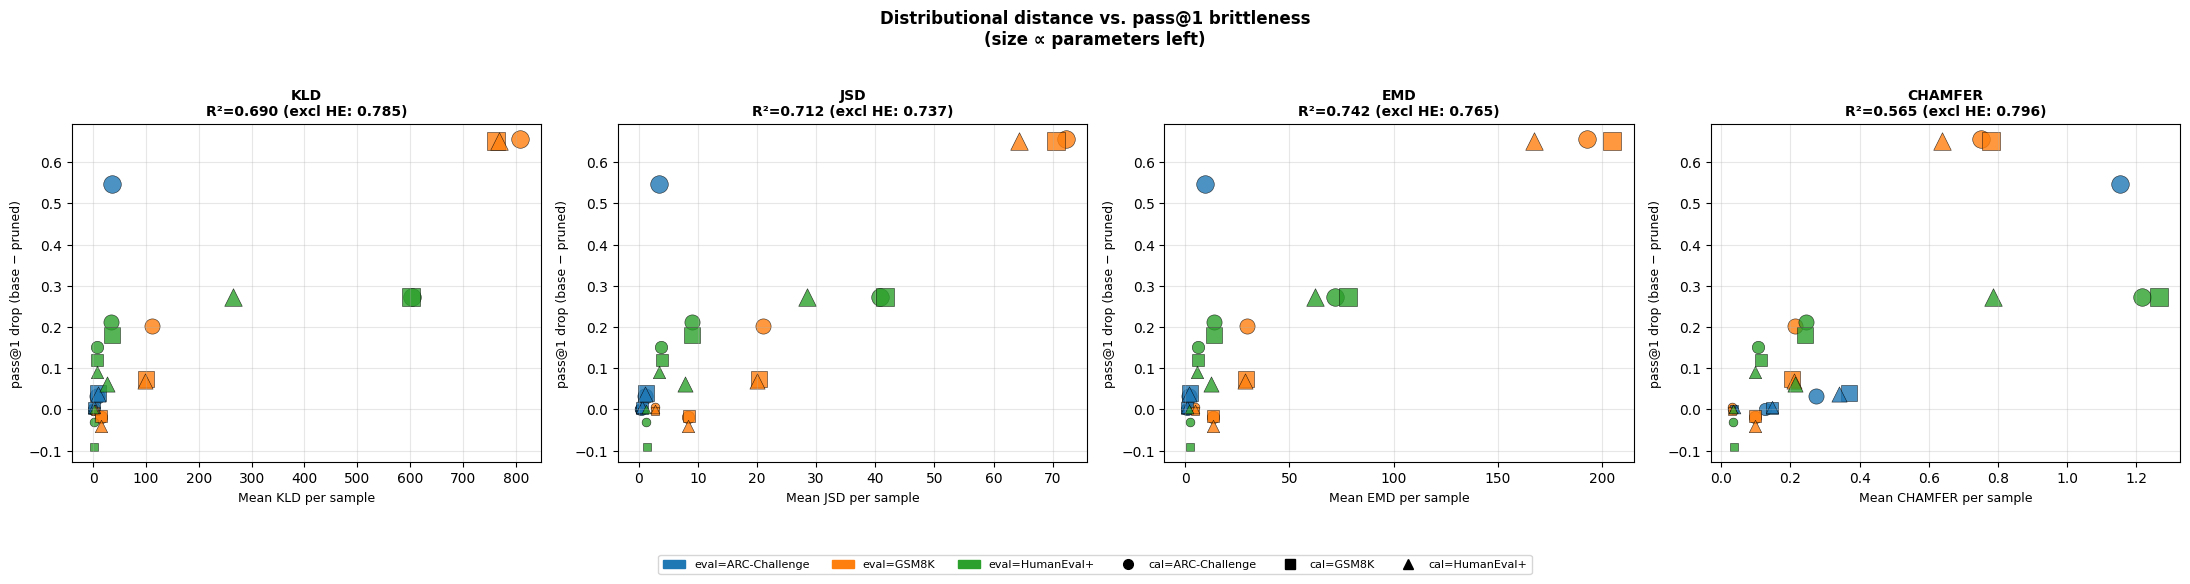

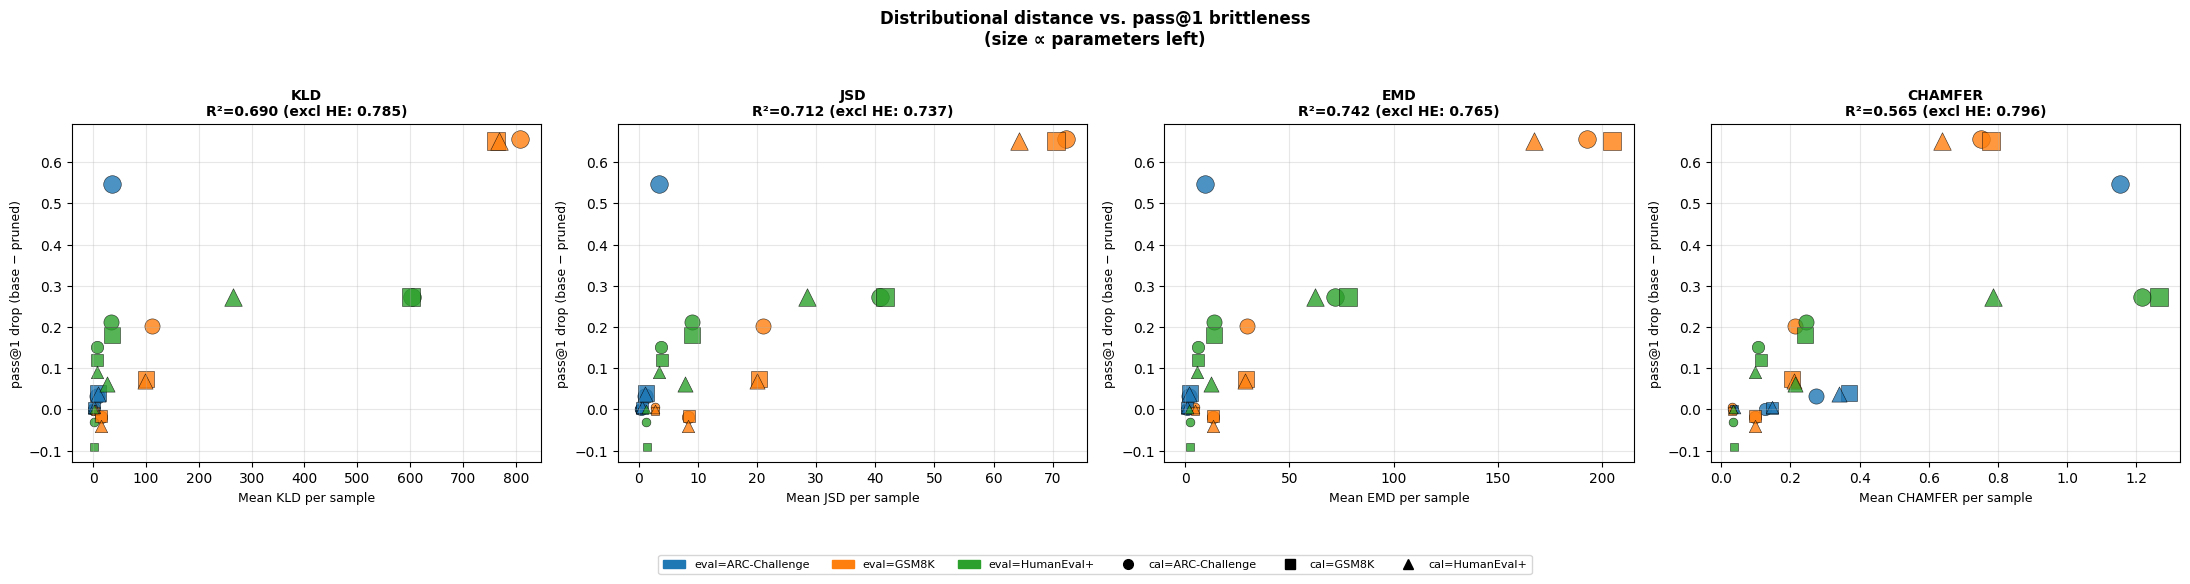

In [11]:
import matplotlib.pyplot as plt

COLORS  = {"arc_challenge": "tab:blue", "gsm8k": "tab:orange", "humaneval": "tab:green"}
MARKERS = {"arc_challenge": "o",       "gsm8k": "s",          "humaneval": "^"}
SIZES   = {20: 200 * 0.2, 40: 200 * 0.4, 60: 200 * 0.6, 80: 200 * 0.8}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, name in zip(axes, METRIC_NAMES):
    col = f"{name}_mean"
    for _, row in combined_df.iterrows():
        ax.scatter(
            row[col], row["pass_at_1_drop"],
            c=COLORS.get(row["eval"], "gray"),
            marker=MARKERS.get(row["cal"], "x"),
            s=SIZES.get(int(row["pruning_level"]), 60),
            alpha=0.8, edgecolors="k", linewidths=0.4,
        )
    r2_row = r2_df[r2_df["metric_col"] == col].iloc[0]
    ax.set_title(
        f"{name.upper()}\nR²={r2_row['r2_all']:.3f} "
        f"(excl HE: {r2_row['r2_no_humaneval']:.3f})",
        fontsize=10, fontweight="bold",
    )
    ax.set_xlabel(f"Mean {name.upper()} per sample", fontsize=9)
    ax.set_ylabel("pass@1 drop (base − pruned)", fontsize=9)
    ax.grid(True, alpha=0.3)

# Legend patches
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
color_patches = [
    mpatches.Patch(color=c, label=f"eval={BENCHMARK_LABELS[k]}")
    for k, c in COLORS.items()
]
marker_lines = [
    mlines.Line2D([], [], color="k", marker=m, linestyle="None",
                  markersize=7, label=f"cal={BENCHMARK_LABELS[k]}")
    for k, m in MARKERS.items()
]
fig.legend(
    handles=color_patches + marker_lines,
    loc="lower center", ncol=6, fontsize=8,
    bbox_to_anchor=(0.5, -0.12),
)
fig.suptitle(
    "Distributional distance vs. pass@1 brittleness\n"
    "(size ∝ parameters left)",
    fontsize=12, fontweight="bold", y=1.02,
)
fig.tight_layout()
fig

## R² bar chart

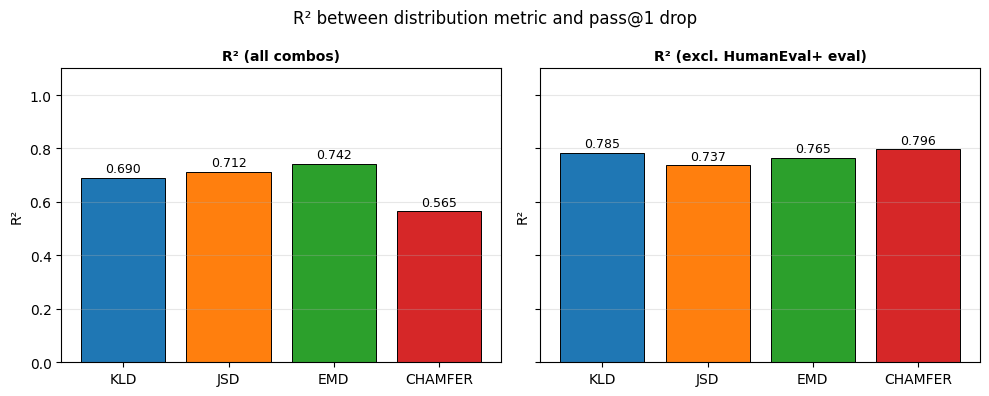

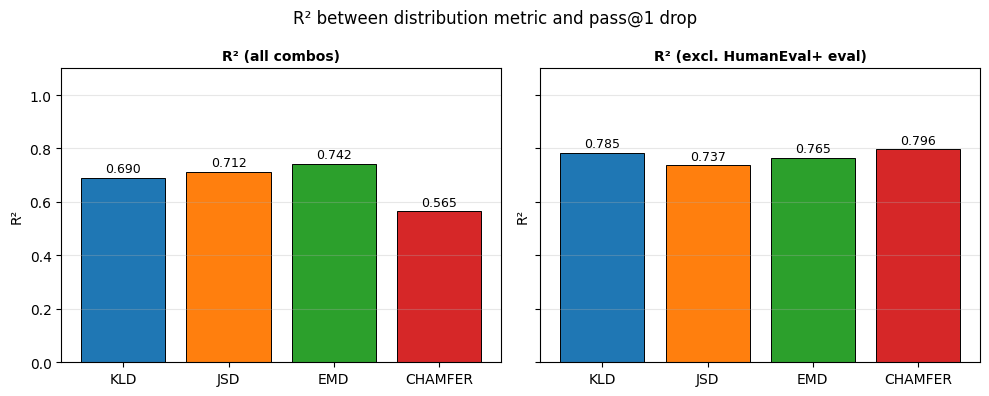

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bar_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = [r["metric"] for r in r2_rows]

for ax, col, title in zip(
    axes,
    ["r2_all", "r2_no_humaneval"],
    ["R² (all combos)", "R² (excl. HumanEval+ eval)"],
):
    vals = [r[col] for r in r2_rows]
    plot_vals = [v if not (v != v) else 0.0 for v in vals]  # NaN → 0 for bar height
    bars = ax.bar(labels, plot_vals, color=bar_colors, edgecolor="k", linewidth=0.7)
    for bar, v in zip(bars, vals):
        label = "N/A" if v != v else f"{v:.3f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, label,
            ha="center", va="bottom", fontsize=9,
        )
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("R²")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("R² between distribution metric and pass@1 drop", fontsize=12)
fig.tight_layout()
fig

## Per-(cal, eval) R² heatmap

For each of the 9 (cal, eval) pairs, R² is computed over the 4 non-zero
pruning levels (20, 40, 60, 80).  Pairs with only 1 matched data point
show N/A.

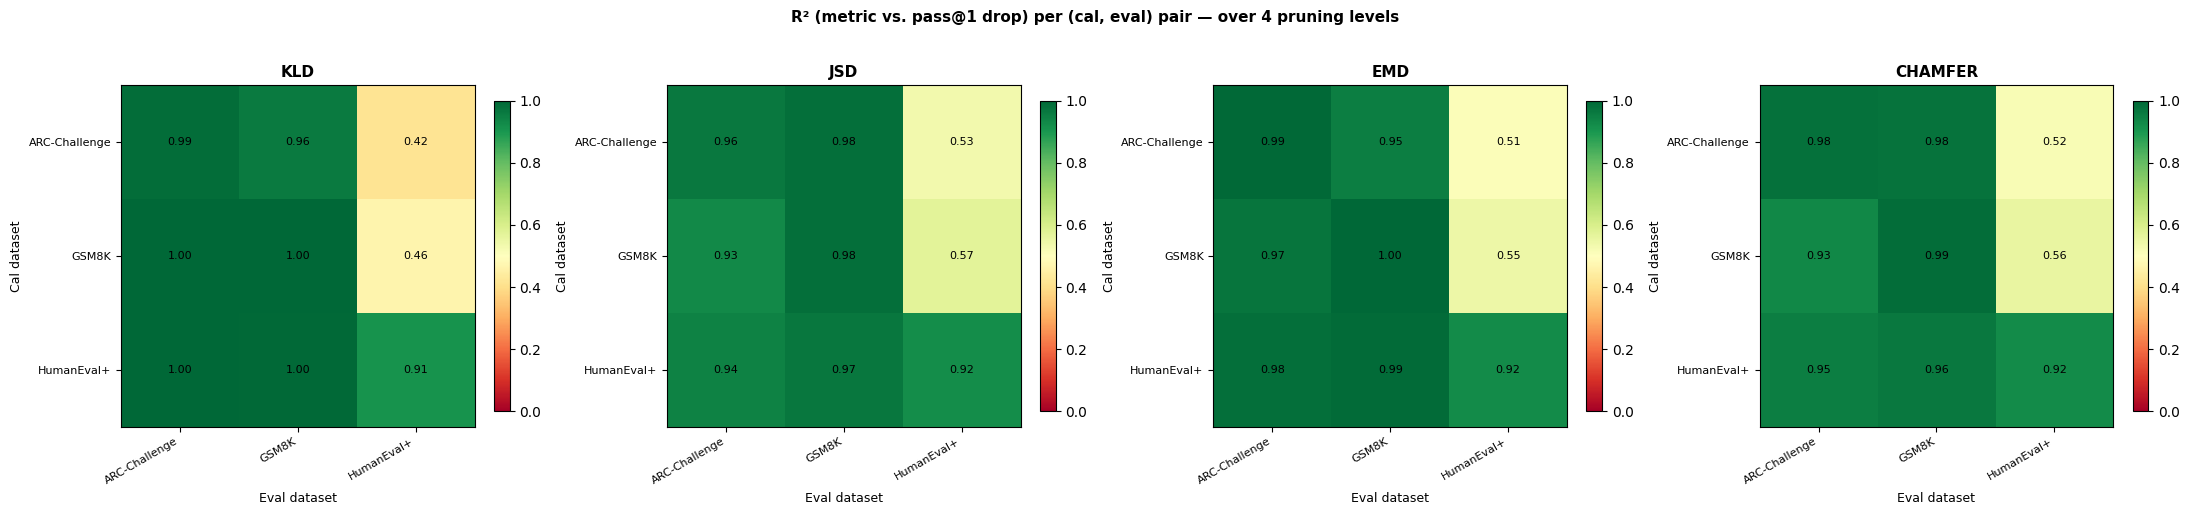

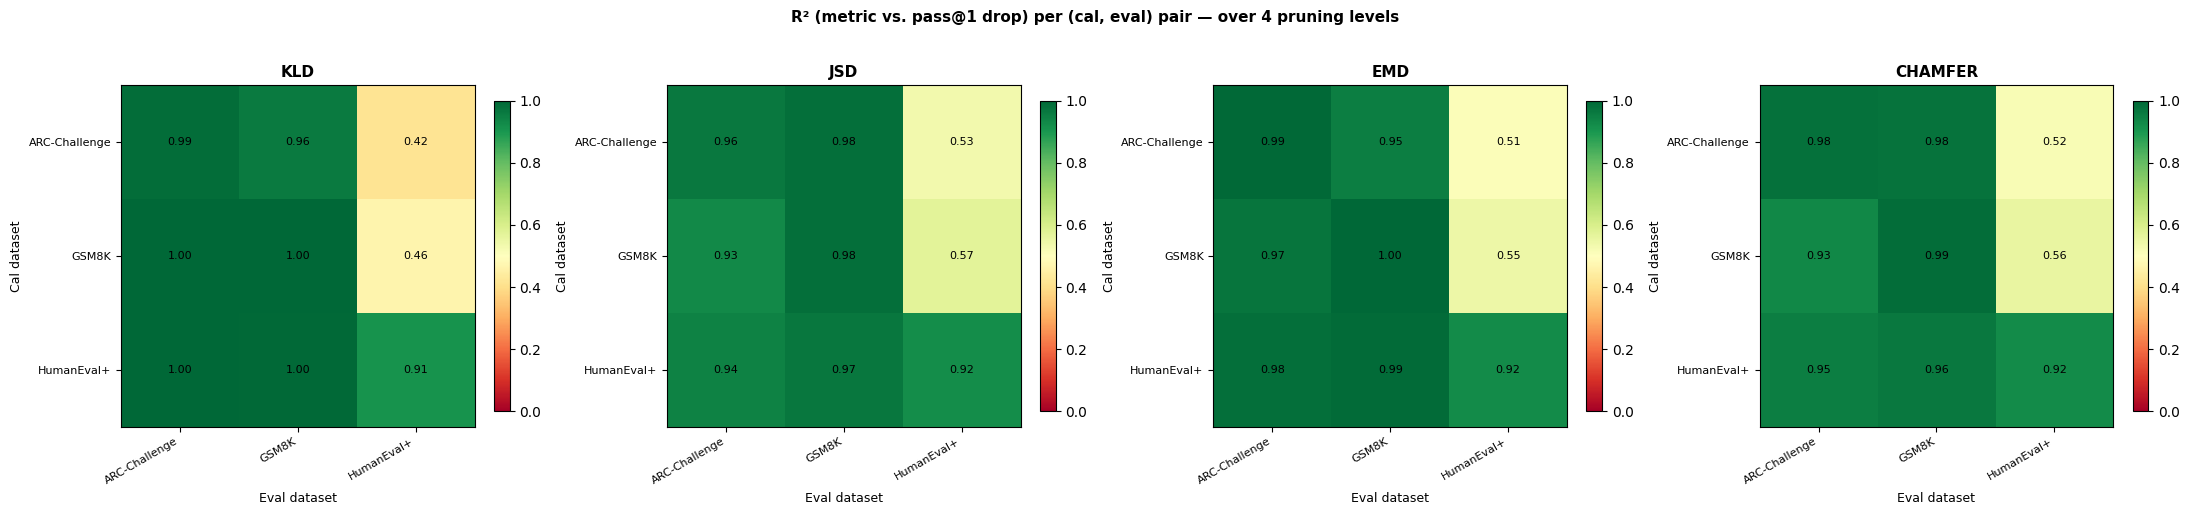

In [13]:
cal_labels  = sorted(DATASETS)
eval_labels = sorted(DATASETS)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, name in zip(axes, METRIC_NAMES):
    col = f"{name}_mean"
    heatmap = np.full((3, 3), np.nan)
    for ri, cal in enumerate(cal_labels):
        for ci, ev in enumerate(eval_labels):
            subset = combined_df[
                (combined_df["cal"] == cal) & (combined_df["eval"] == ev)
            ]
            if len(subset) >= 2:
                heatmap[ri, ci] = _r2(
                    subset[col].values,
                    subset["pass_at_1_drop"].values,
                )
    im = ax.imshow(heatmap, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3))
    ax.set_xticklabels(
        [BENCHMARK_LABELS[e] for e in eval_labels],
        rotation=30, ha="right", fontsize=8,
    )
    ax.set_yticks(range(3))
    ax.set_yticklabels([BENCHMARK_LABELS[c] for c in cal_labels], fontsize=8)
    ax.set_xlabel("Eval dataset", fontsize=9)
    ax.set_ylabel("Cal dataset", fontsize=9)
    ax.set_title(name.upper(), fontsize=11, fontweight="bold")
    for ri in range(3):
        for ci in range(3):
            v = heatmap[ri, ci]
            label = "N/A" if np.isnan(v) else f"{v:.2f}"
            ax.text(ci, ri, label, ha="center", va="center",
                    fontsize=8, color="black" if not np.isnan(v) else "gray")
    plt.colorbar(im, ax=ax, fraction=0.04)

fig.suptitle(
    "R² (metric vs. pass@1 drop) per (cal, eval) pair — over 4 pruning levels",
    fontsize=11, fontweight="bold", y=1.02,
)
fig.tight_layout()
fig

## Save results

In [14]:
RESULTS_DIR.mkdir(exist_ok=True)

metric_csv   = RESULTS_DIR / "metric_space_distances.csv"
combined_csv = RESULTS_DIR / "metric_space_combined.csv"
r2_csv       = RESULTS_DIR / "metric_space_r2.csv"

metric_df.to_csv(metric_csv,   index=False)
combined_df.to_csv(combined_csv, index=False)
r2_df.to_csv(r2_csv,           index=False)

print("Saved:")
print(f"  {metric_csv}    ({len(metric_df)} rows)")
print(f"  {combined_csv}  ({len(combined_df)} rows)")
print(f"  {r2_csv}        ({len(r2_df)} rows)")

Saved:
  /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/metric_space_distances.csv    (36 rows)
  /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/metric_space_combined.csv  (34 rows)
  /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/metric_space_r2.csv        (4 rows)
